**Geogrpahical analysis.*** EStiamtion of country centroids. OD matrix and Analyitical Geographic estiamtion

In [3]:
import sys
print("Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install geopandas


Python: c:\Users\ROBERTODU\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [ ]:
import geopandas as gpd
print(gpd.__version__)


1.1.2


In [3]:
import sys
print("Python:", sys.executable)

!{sys.executable} -m pip install requests


Python: c:\Users\ROBERTODU\AppData\Local\Python\pythoncore-3.14-64\python.exe

   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------- ----------------------------- 1/4 [idna]
   ---------- ----------------------------- 1/4 [idna]
   ---------- ----------------------------- 1/4 [idna]
   -------------------- ------------------- 2/4 [charset_normalizer]
   -------------------- ------------------- 2/4 [charset_normalizer]
   -------------------- ------------------- 2/4 [charset_normalizer]
   ------------------------------ --------- 3/4 [requests]
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


**1. Cell 1 — Imports and configuration***

In [5]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import requests


In [6]:
# Working directory
WORKDIR = Path(r"C:\Python\trade\geo")

# Inputs / outputs
CODES_CSV = WORKDIR / "codes.csv"
CENTROIDS_OUT = WORKDIR / "country_centroids_augmented.csv"
OD_OUT = WORKDIR / "OD_Matrix.csv"

# Historic → modern mapping
HISTORIC_TO_MODERN = {
    "ANS": "CUW",
    "ANT": "CUW",
    "CSK": "CZE",
    "DDR": "DEU",
    "NTZ": "SAU",
    "PCI": "FSM",
    "PCZ": "PAN",
    "PUS": "UMI",
    "SCG": "SRB",
    "SUN": "RUS",
    "YMD": "YEM",
    "YUG": "SRB",
}

# Natural Earth (auto-download)
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
NE_ZIP = WORKDIR / "ne_110m_admin_0_countries.zip"
NE_DIR = WORKDIR / "ne_110m_admin_0_countries"
NE_SHP = NE_DIR / "ne_110m_admin_0_countries.shp"

print("Config loaded.")


Config loaded.


**Cell 2 — Utility functions**

In [7]:
def log(msg):
    print(f"[INFO] {msg}")


In [8]:
def download_file(url, dest):
    if dest.exists() and dest.stat().st_size > 0:
        log("Natural Earth zip already exists.")
        return
    log("Downloading Natural Earth boundaries …")
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    log("Download complete.")


In [9]:
def unzip(zip_path, out_dir):
    if any(out_dir.glob("*.shp")):
        log("Natural Earth shapefile already extracted.")
        return
    log("Extracting Natural Earth shapefile …")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    log("Extraction complete.")


In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


**Cell 3 — Read codes.csv**

In [11]:
log("Reading codes.csv …")

if not CODES_CSV.exists():
    raise FileNotFoundError(f"Missing {CODES_CSV}")

codes_df = pd.read_csv(CODES_CSV)
if "code" not in codes_df.columns:
    raise ValueError("codes.csv must have a column named 'code'")

codes = (
    codes_df["code"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .unique()
    .tolist()
)

codes = sorted(codes)

log(f"Loaded {len(codes)} country codes.")
codes[:10]


[INFO] Reading codes.csv …
[INFO] Loaded 252 country codes.


['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'AND', 'ANS', 'ANT', 'ARE', 'ARG']

**Cell 4 — Download and load Natural Earth**

In [12]:
log("Preparing Natural Earth geometry …")

download_file(NE_URL, NE_ZIP)
unzip(NE_ZIP, NE_DIR)

if not NE_SHP.exists():
    raise FileNotFoundError("Natural Earth shapefile not found.")

world = gpd.read_file(NE_SHP).to_crs(epsg=4326)

log(f"Loaded {len(world)} polygons from Natural Earth.")
world.head()


[INFO] Preparing Natural Earth geometry …
[INFO] Downloading Natural Earth boundaries …
[INFO] Download complete.
[INFO] Extracting Natural Earth shapefile …
[INFO] Extraction complete.
[INFO] Loaded 177 polygons from Natural Earth.


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


**Cell 5 — Compute modern centroids**

In [13]:
log("Computing modern centroids …")

iso = world["ISO_A3"].astype(str).values
adm = world["ADM0_A3"].astype(str).values
code = np.where(iso != "-99", iso, adm)

world = world.assign(code=code)

pts = world.geometry.representative_point()

centroids_modern = pd.DataFrame({
    "code": world["code"].astype(str).values,
    "lat": pts.y.values,
    "lon": pts.x.values,
    "name": world.get("ADMIN", ""),
    "assigned_from": ""
})

centroids_modern = (
    centroids_modern
    .dropna(subset=["code", "lat", "lon"])
    .drop_duplicates(subset=["code"])
    .reset_index(drop=True)
)

log(f"Computed centroids for {len(centroids_modern)} modern jurisdictions.")
centroids_modern.head()


[INFO] Computing modern centroids …
[INFO] Computed centroids for 177 modern jurisdictions.


,code,lat,lon,name,assigned_from
0,FJI,-17.937620,177.975949,Fiji,
1,TZA,-6.207829,34.142071,United Republic of Tanzania,
2,ESH,24.230563,-12.572015,Western Sahara,
3,CAN,56.701920,-110.243808,Canada,
4,USA,37.236745,-99.314832,United States of America,


**Diagnostic Codes Natural Earth

In [16]:
# Diagnostic — coverage of Natural Earth vs your codes.csv

ne_codes = set(centroids_modern["code"].astype(str))
your_codes = set(pd.Series(codes).astype(str))

missing_ne = sorted(your_codes - ne_codes)

print(f"[INFO] Natural Earth codes available: {len(ne_codes)}")
print(f"[INFO] Your code universe (codes.csv): {len(your_codes)}")
print(f"[INFO] Missing from Natural Earth: {len(missing_ne)}")

# Classify missing codes
missing_historic = sorted([c for c in missing_ne if c in HISTORIC_TO_MODERN])
missing_manual = sorted([c for c in missing_ne if c not in HISTORIC_TO_MODERN])

print(f"[INFO] Missing but covered by HISTORIC_TO_MODERN mapping: {len(missing_historic)}")
print(f"[INFO] Missing and NOT covered (needs manual centroid or alternative geometry source): {len(missing_manual)}")

print("\n--- Missing (historic-mapped) ---")
print(missing_historic)

print("\n--- Missing (needs manual / alternative) ---")
print(missing_manual)


[INFO] Natural Earth codes available: 177
[INFO] Your code universe (codes.csv): 252
[INFO] Missing from Natural Earth: 79
[INFO] Missing but covered by HISTORIC_TO_MODERN mapping: 12
[INFO] Missing and NOT covered (needs manual centroid or alternative geometry source): 67

--- Missing (historic-mapped) ---
['ANS', 'ANT', 'CSK', 'DDR', 'NTZ', 'PCI', 'PCZ', 'PUS', 'SCG', 'SUN', 'YMD', 'YUG']

--- Missing (needs manual / alternative) ---
['ABW', 'AIA', 'AND', 'ASM', 'ATG', 'BES', 'BHR', 'BLM', 'BMU', 'BRB', 'BVT', 'CCK', 'COK', 'COM', 'CPV', 'CUW', 'CXR', 'CYM', 'DMA', 'FRO', 'FSM', 'GIB', 'GLP', 'GRD', 'GUF', 'GUM', 'HKG', 'HMD', 'IOT', 'KIR', 'KNA', 'LCA', 'MAC', 'MDV', 'MHL', 'MLT', 'MNP', 'MSR', 'MTQ', 'MUS', 'MYT', 'NFK', 'NIU', 'NRU', 'PCN', 'PLW', 'PYF', 'REU', 'SGP', 'SGS', 'SHN', 'SMR', 'SPM', 'STP', 'SXM', 'SYC', 'TCA', 'TKL', 'TON', 'TUV', 'UMI', 'VAT', 'VCT', 'VGB', 'VIR', 'WLF', 'WSM']


In [18]:
# Diagnostic — coverage of Natural Earth vs codes.csv + historic mapping viability
# Produces reports in WORKDIR:
#   1) audit_missing_codes.csv
#   2) audit_historic_mapping_report.csv

import pandas as pd

# Sets
ne_codes = set(centroids_modern["code"].astype(str))
your_codes = set(pd.Series(codes).astype(str))

missing_ne = sorted(your_codes - ne_codes)

print(f"[INFO] Natural Earth codes available: {len(ne_codes)}")
print(f"[INFO] Your code universe (codes.csv): {len(your_codes)}")
print(f"[INFO] Missing from Natural Earth: {len(missing_ne)}")

# Identify historic jurisdictions (by your mapping dict keys)
missing_historic = sorted([c for c in missing_ne if c in HISTORIC_TO_MODERN])
missing_nonhistoric = sorted([c for c in missing_ne if c not in HISTORIC_TO_MODERN])

print(f"[INFO] Missing historic jurisdictions (in HISTORIC_TO_MODERN keys): {len(missing_historic)}")
print(f"[INFO] Missing non-historic codes: {len(missing_nonhistoric)}")

# --- Report 1: all missing codes with a basic classification ---
missing_report = pd.DataFrame({
    "code": missing_ne,
    "is_historic": [c in HISTORIC_TO_MODERN for c in missing_ne],
    "historic_maps_to": [HISTORIC_TO_MODERN.get(c, "") for c in missing_ne],
    "mapped_target_in_natural_earth": [
        (HISTORIC_TO_MODERN.get(c, "") in ne_codes) if c in HISTORIC_TO_MODERN else ""
        for c in missing_ne
    ],
})
missing_report_path = WORKDIR / "audit_missing_codes.csv"
missing_report.to_csv(missing_report_path, index=False)
print(f"[INFO] Wrote: {missing_report_path}")

# --- Report 2: deep dive only for historic jurisdictions ---
hist_rows = []
for h in HISTORIC_TO_MODERN.keys():
    target = HISTORIC_TO_MODERN[h]
    hist_rows.append({
        "historic_code": h,
        "historic_in_your_codes": (h in your_codes),
        "historic_in_natural_earth": (h in ne_codes),
        "maps_to": target,
        "target_in_your_codes": (target in your_codes),
        "target_in_natural_earth": (target in ne_codes),
        "status": (
            "OK_direct" if (h in your_codes and h not in ne_codes and target in ne_codes) else
            "NE_has_historic" if (h in ne_codes) else
            "needs_extra_rule" if (h in your_codes and h not in ne_codes and target not in ne_codes) else
            "not_used"  # historic mapping exists but code not in your codes.csv
        )
    })

historic_report = pd.DataFrame(hist_rows).sort_values(["status", "historic_code"]).reset_index(drop=True)
historic_report_path = WORKDIR / "audit_historic_mapping_report.csv"
historic_report.to_csv(historic_report_path, index=False)
print(f"[INFO] Wrote: {historic_report_path}")

# --- Console summary for the key risk you highlighted ---
needs_extra = historic_report[historic_report["status"] == "needs_extra_rule"]
ok_direct = historic_report[historic_report["status"] == "OK_direct"]
not_used = historic_report[historic_report["status"] == "not_used"]

print("\n[INFO] Historic mapping summary")
print(f"  OK_direct (historic missing, target present in NE): {len(ok_direct)}")
print(f"  needs_extra_rule (historic missing, target also missing in NE): {len(needs_extra)}")
print(f"  not_used (historic code not in your codes.csv): {len(not_used)}")

if len(needs_extra) > 0:
    print("\n--- Historic mappings that NEED extra rule (target not in NE) ---")
    print(needs_extra[["historic_code", "maps_to", "target_in_natural_earth"]].to_string(index=False))

print("\n--- Missing historic codes (present in codes.csv but absent in NE) ---")
print(missing_historic)

print("\n--- Missing non-historic codes (present in codes.csv but absent in NE) ---")
print(missing_nonhistoric)


[INFO] Natural Earth codes available: 177
[INFO] Your code universe (codes.csv): 252
[INFO] Missing from Natural Earth: 79
[INFO] Missing historic jurisdictions (in HISTORIC_TO_MODERN keys): 12
[INFO] Missing non-historic codes: 67
[INFO] Wrote: C:\Python\trade\geo\audit_missing_codes.csv
[INFO] Wrote: C:\Python\trade\geo\audit_historic_mapping_report.csv

[INFO] Historic mapping summary
  OK_direct (historic missing, target present in NE): 8
  needs_extra_rule (historic missing, target also missing in NE): 4
  not_used (historic code not in your codes.csv): 0

--- Historic mappings that NEED extra rule (target not in NE) ---
historic_code maps_to  target_in_natural_earth
          ANS     CUW                    False
          ANT     CUW                    False
          PCI     FSM                    False
          PUS     UMI                    False

--- Missing historic codes (present in codes.csv but absent in NE) ---
['ANS', 'ANT', 'CSK', 'DDR', 'NTZ', 'PCI', 'PCZ', 'PUS', 'S

**Cell 6 — Resolve historic / missing codes**

In [26]:
# Cell 6 — Resolve historic / missing codes, prefer explicit coords, chaining-safe, + audit reports
# POLICY:
#   1) Use Natural Earth centroid if available
#   2) Else use MANUAL_CENTROIDS if provided (preferred over parent-sovereign fallback)
#   3) Else resolve via HISTORIC_TO_MODERN (and repeat)
#   4) Else resolve via TERRITORY_TO_SOVEREIGN (and repeat)
#   5) Else unresolved
#
# Audit outputs in WORKDIR:
#   - audit_natural_earth_codes_present.csv
#   - audit_missing_codes_from_natural_earth.csv
#   - audit_historic_mapping_report.csv
#   - audit_resolution_methods.csv        <-- key: shows which method used per code
#   - audit_unresolved_codes.csv          (only if unresolved remain)

log("Resolving centroids for full country universe + writing audit outputs …")

# --- Territory → sovereign fallback mapping (use only if no explicit coords available) ---
TERRITORY_TO_SOVEREIGN = {
    # Netherlands
    "ABW": "NLD", "BES": "NLD", "CUW": "NLD", "SXM": "NLD",

    # United Kingdom
    "AIA": "GBR", "BMU": "GBR", "CYM": "GBR", "GIB": "GBR",
    "MSR": "GBR", "SHN": "GBR", "TCA": "GBR", "VGB": "GBR",
    "SGS": "GBR", "IOT": "GBR",

    # France
    "BLM": "FRA", "GLP": "FRA", "GUF": "FRA", "MTQ": "FRA",
    "MYT": "FRA", "REU": "FRA", "SPM": "FRA", "WLF": "FRA",
    "PYF": "FRA",

    # United States
    "ASM": "USA", "GUM": "USA", "MNP": "USA", "VIR": "USA", "UMI": "USA",

    # China (customs areas)
    "HKG": "CHN", "MAC": "CHN",

    # Australia / NZ
    "CCK": "AUS", "CXR": "AUS", "NFK": "AUS", "HMD": "AUS",
    "COK": "NZL", "TKL": "NZL",

    # Denmark
    "FRO": "DNK",

    # Norway
    "BVT": "NOR",
}

# --- Manual centroids (you can expand this aggressively over time) ---
# Strong recommendation: add territories here if you can. This will override parent-sovereign fallback.
# Format: "CODE": (lat, lon)
MANUAL_CENTROIDS = {
    # Sovereign micro-states (examples)
    "AND": (42.5462, 1.6016),
    "ATG": (17.0608, -61.7964),
    "BHR": (26.0667, 50.5577),
    "BRB": (13.1939, -59.5432),
    "COM": (-11.6455, 43.3333),
    "CPV": (15.1111, -23.6167),
    "DMA": (15.4150, -61.3710),
    "FSM": (6.9248, 158.1620),
    "GRD": (12.1165, -61.6790),
    "KIR": (1.4518, 173.0329),
    "KNA": (17.3578, -62.7830),
    "LCA": (13.9094, -60.9789),
    "MDV": (3.2028, 73.2207),
    "MHL": (7.1315, 171.1845),
    "MLT": (35.9375, 14.3754),
    "MUS": (-20.3484, 57.5522),
    "NIU": (-19.0544, -169.8672),
    "NRU": (-0.5228, 166.9315),
    "PCN": (-24.3768, -128.3242),
    "PLW": (7.5150, 134.5825),
    "SGP": (1.3521, 103.8198),
    "SMR": (43.9424, 12.4578),
    "STP": (0.1864, 6.6131),
    "SYC": (-4.6796, 55.4920),
    "TON": (-21.1790, -175.1982),
    "TUV": (-7.1095, 177.6493),
    "VAT": (41.9029, 12.4534),
    "VCT": (13.2528, -61.1971),
    "WSM": (-13.7590, -172.1046),
    
"ABW": (12.5211, -69.9683),   # Aruba (Oranjestad)
"BES": (12.1784, -68.2385),   # Caribbean Netherlands (Bonaire)
"CUW": (12.1696, -68.9900),   # Curaçao (Willemstad)
"SXM": (18.0425, -63.0548),   # Sint Maarten (Philipsburg)

"AIA": (18.2206, -63.0686),   # Anguilla (The Valley)
"BMU": (32.2949, -64.7814),   # Bermuda (Hamilton)
"CYM": (19.3133, -81.2546),   # Cayman Islands (George Town)
"GIB": (36.1408, -5.3536),    # Gibraltar
"MSR": (16.7425, -62.1874),   # Montserrat (Brades)
"SHN": (-15.9650, -5.7089),   # Saint Helena (Jamestown)
"TCA": (21.6940, -71.7979),   # Turks & Caicos (Cockburn Town)
"VGB": (18.4286, -64.6185),   # British Virgin Islands (Road Town)
"SGS": (-54.4296, -36.5879),  # South Georgia (King Edward Point)
"IOT": (-7.3340, 72.4240),    # British Indian Ocean Territory (Diego Garcia)

"BLM": (17.8962, -62.8498),   # Saint Barthélemy (Gustavia)
"GLP": (16.2650, -61.5510),   # Guadeloupe (Basse-Terre)
"GUF": (4.9372, -52.3260),    # French Guiana (Cayenne)
"MTQ": (14.6161, -61.0588),   # Martinique (Fort-de-France)
"MYT": (-12.8275, 45.1662),   # Mayotte (Mamoudzou)
"REU": (-20.8789, 55.4481),   # Réunion (Saint-Denis)
"SPM": (46.7770, -56.1773),   # Saint Pierre & Miquelon
"WLF": (-13.2825, -176.1760), # Wallis & Futuna (Mata-Utu)
"PYF": (-17.5516, -149.5585), # French Polynesia (Papeete)

"ASM": (-14.2710, -170.1322), # American Samoa (Pago Pago)
"GUM": (13.4443, 144.7937),   # Guam (Hagåtña)
"MNP": (15.2123, 145.7545),   # Northern Mariana Islands (Saipan)
"VIR": (18.3358, -64.8963),   # U.S. Virgin Islands (Charlotte Amalie)
"UMI": (19.2823, 166.6470),   # U.S. Minor Outlying Islands (Wake Island ref.)

"HKG": (22.3193, 114.1694),   # Hong Kong
"MAC": (22.1987, 113.5439),   # Macau

"CCK": (-12.1642, 96.8710),   # Cocos (Keeling) Islands
"CXR": (-10.4475, 105.6904),  # Christmas Island
"NFK": (-29.0333, 167.9500),  # Norfolk Island
"HMD": (-53.0818, 73.5042),   # Heard & McDonald Islands (uninhabited ref.)
"COK": (-21.2367, -159.7777), # Cook Islands (Avarua)
"TKL": (-9.2002, -171.8484),  # Tokelau (Atafu ref.)

"FRO": (62.0079, -6.7900),    # Faroe Islands (Tórshavn)

"BVT": (-54.4208, 3.3464),    # Bouvet Island (uninhabited ref.)
 

}

# -------------------------
# Coverage diagnostics (NE vs your codes.csv)
# -------------------------
ne_codes = set(centroids_modern["code"].astype(str))
your_codes = set(pd.Series(codes).astype(str))
missing_ne = sorted(your_codes - ne_codes)

missing_historic = sorted([c for c in missing_ne if c in HISTORIC_TO_MODERN])
missing_nonhistoric = sorted([c for c in missing_ne if c not in HISTORIC_TO_MODERN])

log(f"Natural Earth codes available: {len(ne_codes)}")
log(f"Your code universe (codes.csv): {len(your_codes)}")
log(f"Missing from Natural Earth: {len(missing_ne)}")
log(f"Missing historic jurisdictions: {len(missing_historic)}")
log(f"Missing non-historic codes: {len(missing_nonhistoric)}")

# audit: NE present codes
ne_present_path = WORKDIR / "audit_natural_earth_codes_present.csv"
centroids_modern[["code", "name"]].drop_duplicates().sort_values("code").to_csv(ne_present_path, index=False)
log(f"Wrote: {ne_present_path}")

# audit: missing codes classification
missing_audit_path = WORKDIR / "audit_missing_codes_from_natural_earth.csv"
pd.DataFrame({
    "code": missing_ne,
    "is_historic": [c in HISTORIC_TO_MODERN for c in missing_ne],
    "historic_maps_to": [HISTORIC_TO_MODERN.get(c, "") for c in missing_ne],
    "historic_target_in_ne": [(HISTORIC_TO_MODERN.get(c, "") in ne_codes) if c in HISTORIC_TO_MODERN else "" for c in missing_ne],
    "is_territory_fallback": [c in TERRITORY_TO_SOVEREIGN for c in missing_ne],
    "territory_maps_to": [TERRITORY_TO_SOVEREIGN.get(c, "") for c in missing_ne],
    "territory_target_in_ne": [(TERRITORY_TO_SOVEREIGN.get(c, "") in ne_codes) if c in TERRITORY_TO_SOVEREIGN else "" for c in missing_ne],
    "has_manual_centroid": [c in MANUAL_CENTROIDS for c in missing_ne],
}).to_csv(missing_audit_path, index=False)
log(f"Wrote: {missing_audit_path}")

# audit: historic viability
hist_rows = []
for h, target in HISTORIC_TO_MODERN.items():
    hist_rows.append({
        "historic_code": h,
        "historic_in_your_codes": (h in your_codes),
        "historic_in_ne": (h in ne_codes),
        "maps_to": target,
        "target_in_ne": (target in ne_codes),
        "target_has_manual": (target in MANUAL_CENTROIDS),
        "target_is_territory_fallback": (target in TERRITORY_TO_SOVEREIGN),
    })
historic_report = pd.DataFrame(hist_rows)
historic_report_path = WORKDIR / "audit_historic_mapping_report.csv"
historic_report.to_csv(historic_report_path, index=False)
log(f"Wrote: {historic_report_path}")

# -------------------------
# Resolver: prefer MANUAL over territory fallback, supports chaining
# -------------------------
c_index = centroids_modern.set_index("code")[["lat", "lon", "name"]]

def resolve_to_centroid(code: str, max_hops: int = 8):
    """
    Returns dict: lat, lon, source_code, method, path
    method in {NE, MANUAL, HIST_CHAIN, TERR_CHAIN}
    """
    seen = []
    cur = code
    used_hist = False
    used_terr = False

    for _ in range(max_hops):
        seen.append(cur)

        if cur in c_index.index:
            method = "NE"
            if used_hist and not used_terr:
                method = "HIST_CHAIN"
            elif used_terr and not used_hist:
                method = "TERR_CHAIN"
            elif used_hist and used_terr:
                method = "HIST+TERR_CHAIN"
            return {
                "lat": float(c_index.loc[cur, "lat"]),
                "lon": float(c_index.loc[cur, "lon"]),
                "source_code": cur,
                "method": method,
                "path": "->".join(seen),
            }

        # prefer explicit manual coordinates before any further mapping
        if cur in MANUAL_CENTROIDS:
            lat, lon = MANUAL_CENTROIDS[cur]
            method = "MANUAL"
            if used_hist and not used_terr:
                method = "HIST+MANUAL"
            elif used_terr and not used_hist:
                method = "TERR+MANUAL"
            elif used_hist and used_terr:
                method = "HIST+TERR+MANUAL"
            return {
                "lat": float(lat),
                "lon": float(lon),
                "source_code": "MANUAL",
                "method": method,
                "path": "->".join(seen),
            }

        if cur in HISTORIC_TO_MODERN:
            used_hist = True
            cur = HISTORIC_TO_MODERN[cur]
            continue

        if cur in TERRITORY_TO_SOVEREIGN:
            used_terr = True
            cur = TERRITORY_TO_SOVEREIGN[cur]
            continue

        break

    return None


# -------------------------
# Build rows for codes missing in NE + resolution report
# -------------------------
rows = []
resolution_rows = []
unresolved = []

for code in missing_ne:
    resolved = resolve_to_centroid(code)
    if resolved is None:
        unresolved.append(code)
        resolution_rows.append({
            "code": code,
            "resolved": False,
            "method": "",
            "path": "",
            "source_code": "",
        })
        continue

    log(f"Resolved {code} via {resolved['path']} ({resolved['method']})")

    rows.append({
        "code": code,
        "lat": resolved["lat"],
        "lon": resolved["lon"],
        "name": f"{resolved['method']}:{resolved['path']}",
        "assigned_from": resolved["source_code"],
        "resolution_path": resolved["path"],
        "resolution_method": resolved["method"],
    })

    resolution_rows.append({
        "code": code,
        "resolved": True,
        "method": resolved["method"],
        "path": resolved["path"],
        "source_code": resolved["source_code"],
    })

# Write resolution methods report (key to improving manual coords later)
resolution_report_path = WORKDIR / "audit_resolution_methods.csv"
pd.DataFrame(resolution_rows).sort_values(["resolved", "code"]).to_csv(resolution_report_path, index=False)
log(f"Wrote: {resolution_report_path}")

# If unresolved remain, write and fail
if unresolved:
    unresolved_path = WORKDIR / "audit_unresolved_codes.csv"
    pd.DataFrame({"code": unresolved}).to_csv(unresolved_path, index=False)
    log(f"Wrote: {unresolved_path}")
    raise ValueError("Unresolved codes remain after resolver: " + ", ".join(unresolved))

# -------------------------
# Final centroids table (must match codes.csv)
# -------------------------
centroids = pd.concat([centroids_modern, pd.DataFrame(rows)], ignore_index=True)

centroids = (
    centroids[centroids["code"].isin(codes)]
    .drop_duplicates(subset=["code"])
    .sort_values("code")
    .reset_index(drop=True)
)

log(f"Final centroid table: {len(centroids)} entries (expected {len(your_codes)}).")

if len(centroids) != len(your_codes):
    have = set(centroids["code"].astype(str))
    missing_final = sorted(your_codes - have)
    missing_final_path = WORKDIR / "audit_missing_from_final_centroids.csv"
    pd.DataFrame({"code": missing_final}).to_csv(missing_final_path, index=False)
    log(f"Wrote: {missing_final_path}")
    raise ValueError(f"Final centroid table incomplete. Missing {len(missing_final)} codes.")

centroids.tail()


[INFO] Resolving centroids for full country universe + writing audit outputs …
[INFO] Natural Earth codes available: 177
[INFO] Your code universe (codes.csv): 252
[INFO] Missing from Natural Earth: 79
[INFO] Missing historic jurisdictions: 12
[INFO] Missing non-historic codes: 67
[INFO] Wrote: C:\Python\trade\geo\audit_natural_earth_codes_present.csv
[INFO] Wrote: C:\Python\trade\geo\audit_missing_codes_from_natural_earth.csv
[INFO] Wrote: C:\Python\trade\geo\audit_historic_mapping_report.csv
[INFO] Resolved ABW via ABW (MANUAL)
[INFO] Resolved AIA via AIA (MANUAL)
[INFO] Resolved AND via AND (MANUAL)
[INFO] Resolved ANS via ANS->CUW (HIST+MANUAL)
[INFO] Resolved ANT via ANT->CUW (HIST+MANUAL)
[INFO] Resolved ASM via ASM (MANUAL)
[INFO] Resolved ATG via ATG (MANUAL)
[INFO] Resolved BES via BES (MANUAL)
[INFO] Resolved BHR via BHR (MANUAL)
[INFO] Resolved BLM via BLM (MANUAL)
[INFO] Resolved BMU via BMU (MANUAL)
[INFO] Resolved BRB via BRB (MANUAL)
[INFO] Resolved BVT via BVT (MANUAL)


,code,lat,lon,name,assigned_from,resolution_path,resolution_method
247,YMD,15.815314,47.473138,HIST_CHAIN:YMD->YEM,YEM,YMD->YEM,HIST_CHAIN
248,YUG,44.136697,21.013475,HIST_CHAIN:YUG->SRB,SRB,YUG->SRB,HIST_CHAIN
249,ZAF,-28.408524,26.147627,South Africa,,NaN,NaN
250,ZMB,-13.080002,25.369727,Zambia,,NaN,NaN
251,ZWE,-19.003749,29.321721,Zimbabwe,,NaN,NaN


**Cell 7 — Save centroids**

In [27]:
log("Saving centroid file …")
centroids.to_csv(CENTROIDS_OUT, index=False)
CENTROIDS_OUT


[INFO] Saving centroid file …


WindowsPath('C:/Python/trade/geo/country_centroids_augmented.csv')

**Cell 8 — Compute OD matrix (long format)**

In [28]:
log("Computing OD distance matrix …")

ids = centroids["code"].values
lat = centroids["lat"].values
lon = centroids["lon"].values

dist = haversine_km(lat[:, None], lon[:, None], lat[None, :], lon[None, :])

od = pd.DataFrame(dist, index=ids, columns=ids)
od.index.name = "origin"

od_long = (
    od.stack()
      .rename("distance_km")
      .reset_index()
      .rename(columns={"level_0": "origin", "level_1": "destination"})
)

od_long = od_long[od_long["origin"] != od_long["destination"]].reset_index(drop=True)

log(f"OD rows: {len(od_long)} (expected {len(ids)*(len(ids)-1)})")
od_long.head()


[INFO] Computing OD distance matrix …
[INFO] OD rows: 63252 (expected 63252)


,origin,destination,distance_km
0,ABW,AFG,13020.754206
1,ABW,AGO,10162.138512
2,ABW,AIA,973.810060
3,ABW,ALB,9088.470762
4,ABW,AND,7565.620819


**Cell 9 — Save OD matrix**

In [29]:
log("Saving OD matrix …")
od_long.to_csv(OD_OUT, index=False)
OD_OUT


[INFO] Saving OD matrix …


WindowsPath('C:/Python/trade/geo/OD_Matrix.csv')

**Validation**

[INFO] Using centroids file: country_centroids_augmented.csv
[INFO] Total centroids: 252
[INFO] No-problem centroids: 172
[INFO] Problematic centroids: 80


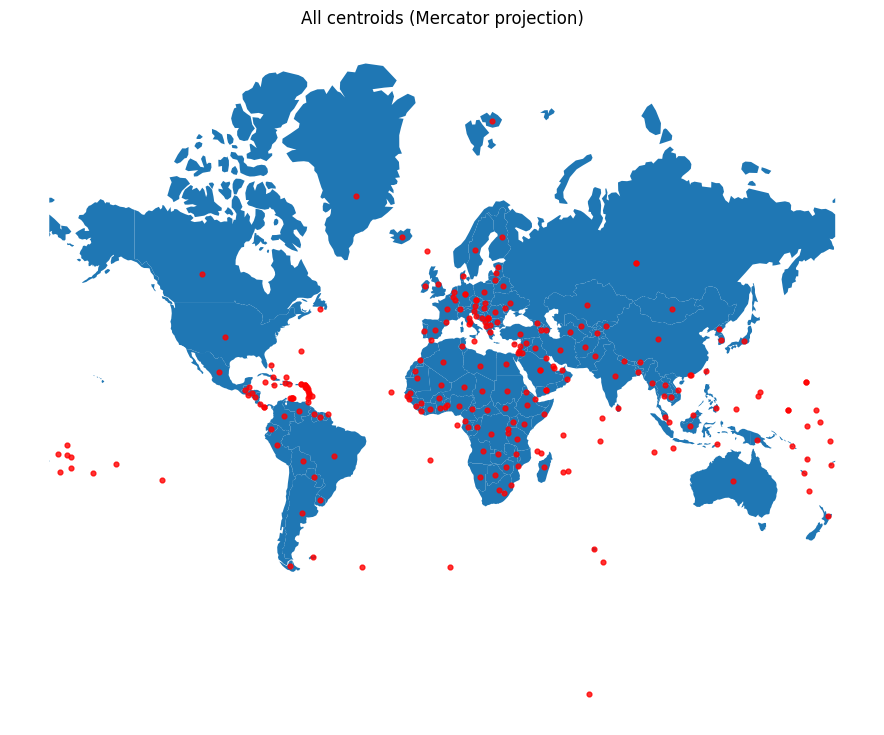

[SAVED] C:\Python\trade\geo\map_all_centroids.png


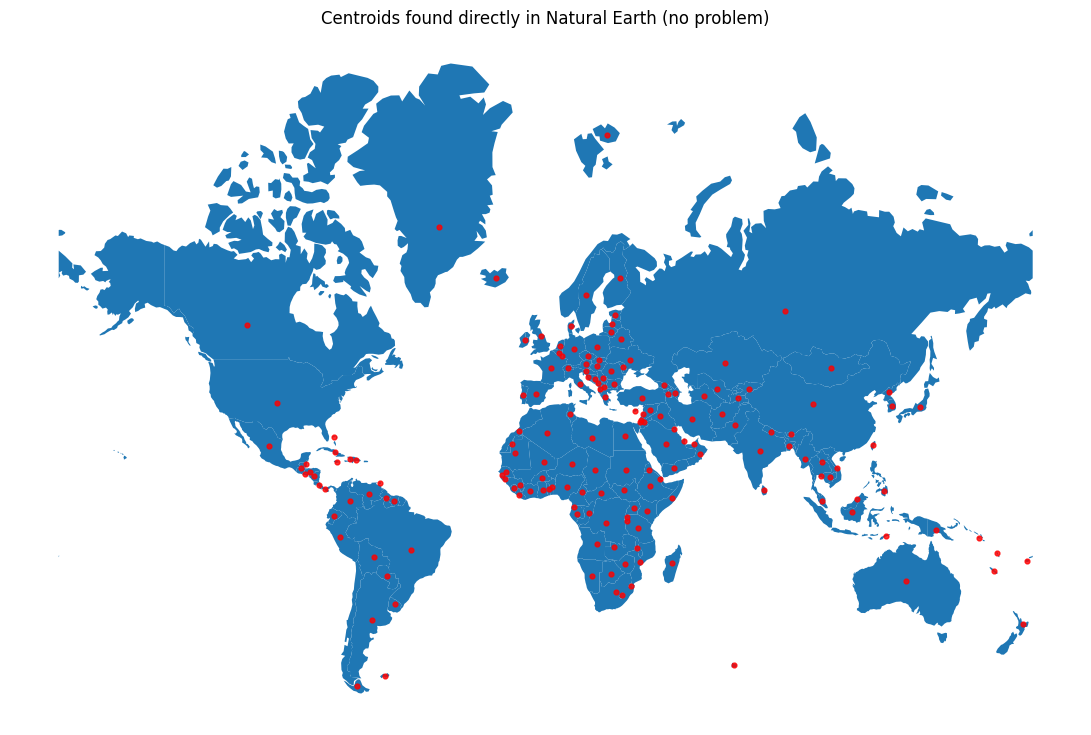

[SAVED] C:\Python\trade\geo\map_no_problem_centroids.png


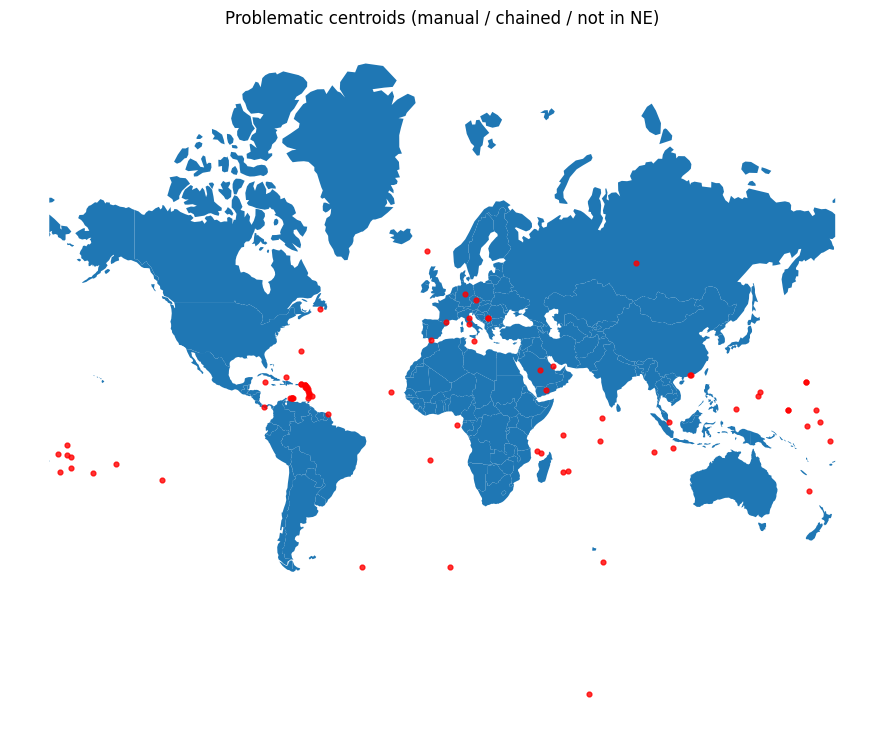

[SAVED] C:\Python\trade\geo\map_problematic_centroids.png


In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------
# Paths
# -------------------------------------------------
WORKDIR = Path(r"C:\Python\trade\geo")

CENTROID_CANDIDATES = [
    WORKDIR / "country_centroids_augmented.csv",
    WORKDIR / "country_centroids.csv",
    WORKDIR / "centroids.csv",
]

centroids_path = next((p for p in CENTROID_CANDIDATES if p.exists()), None)
if centroids_path is None:
    raise FileNotFoundError("Centroids CSV not found in working directory.")

print("[INFO] Using centroids file:", centroids_path.name)
centroids = pd.read_csv(centroids_path)

NE_SHP = WORKDIR / "ne_110m_admin_0_countries" / "ne_110m_admin_0_countries.shp"
if not NE_SHP.exists():
    raise FileNotFoundError("Natural Earth shapefile not found.")

# -------------------------------------------------
# Load basemap and drop Antarctica
# -------------------------------------------------
world = gpd.read_file(NE_SHP)
world = world[world["ISO_A3"] != "ATA"].copy()

if world.crs is None:
    world = world.set_crs("EPSG:4326")
else:
    world = world.to_crs("EPSG:4326")

# -------------------------------------------------
# Build centroid GeoDataFrame
# -------------------------------------------------
g_cent = gpd.GeoDataFrame(
    centroids,
    geometry=gpd.points_from_xy(centroids["lon"], centroids["lat"]),
    crs="EPSG:4326",
)

# -------------------------------------------------
# Project to Web Mercator
# -------------------------------------------------
world_m = world.to_crs(epsg=3857)
g_cent_m = g_cent.to_crs(epsg=3857)

# -------------------------------------------------
# Identify "problematic" centroids
# -------------------------------------------------
iso = world["ISO_A3"].astype(str)
adm = world["ADM0_A3"].astype(str)
ne_code = iso.where(iso != "-99", adm)
ne_codes = set(ne_code.unique())

has_resolution_method = "resolution_method" in g_cent.columns
has_assigned_from = "assigned_from" in g_cent.columns

def is_problematic(row):
    code = str(row["code"])
    if code not in ne_codes:
        return True
    if has_resolution_method and pd.notna(row.get("resolution_method", None)):
        return True
    if has_assigned_from and str(row.get("assigned_from", "")).upper() == "MANUAL":
        return True
    return False

g_cent_m["problematic"] = g_cent_m.apply(is_problematic, axis=1)
g_ok = g_cent_m[~g_cent_m["problematic"]].copy()
g_bad = g_cent_m[g_cent_m["problematic"]].copy()

print(f"[INFO] Total centroids: {len(g_cent_m)}")
print(f"[INFO] No-problem centroids: {len(g_ok)}")
print(f"[INFO] Problematic centroids: {len(g_bad)}")

# -------------------------------------------------
# Plot + save helper
# -------------------------------------------------
def plot_and_save(title, points, filename):
    fig, ax = plt.subplots(figsize=(16, 9))
    world_m.plot(ax=ax, linewidth=0.4)
    points.plot(
        ax=ax,
        color="red",
        markersize=12,
        alpha=0.8
    )
    ax.set_title(title)
    ax.set_axis_off()

    out_path = WORKDIR / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"[SAVED] {out_path}")

# -------------------------------------------------
# 1) All centroids
# -------------------------------------------------
plot_and_save(
    "All centroids (Mercator projection)",
    g_cent_m,
    "map_all_centroids.png"
)

# -------------------------------------------------
# 2) No-problem centroids
# -------------------------------------------------
plot_and_save(
    "Centroids found directly in Natural Earth (no problem)",
    g_ok,
    "map_no_problem_centroids.png"
)

# -------------------------------------------------
# 3) Problematic centroids
# -------------------------------------------------
plot_and_save(
    "Problematic centroids (manual / chained / not in NE)",
    g_bad,
    "map_problematic_centroids.png"
)
